Първи редове от набора от данни:


,year,month,region,apartment_type,avg_price_m2_eur,avg_size_m2,avg_total_price
0,2020,annual,Plovdiv,1-bed,780,55,"42,900"
1,2020,annual,Plovdiv,2-bed,760,80,"60,800"
2,2020,annual,Plovdiv,3-bed,740,105,"77,700"
3,2021,annual,Plovdiv,1-bed,850,55,"46,750"
4,2021,annual,Plovdiv,2-bed,830,80,"66,400"



Средни цени по години:


,year,avg_price_m2_eur
0,2020,760.000000
1,2021,830.000000
2,2022,953.333333
3,2023,1083.333333
4,2024,1220.000000
5,2025,1340.000000
6,2026,1406.666667



Прогнозни стойности:


,year,forecast_price_m2
0,2027,1542.857143
1,2028,1655.952381
2,2029,1768.571428
3,2030,1880.714286


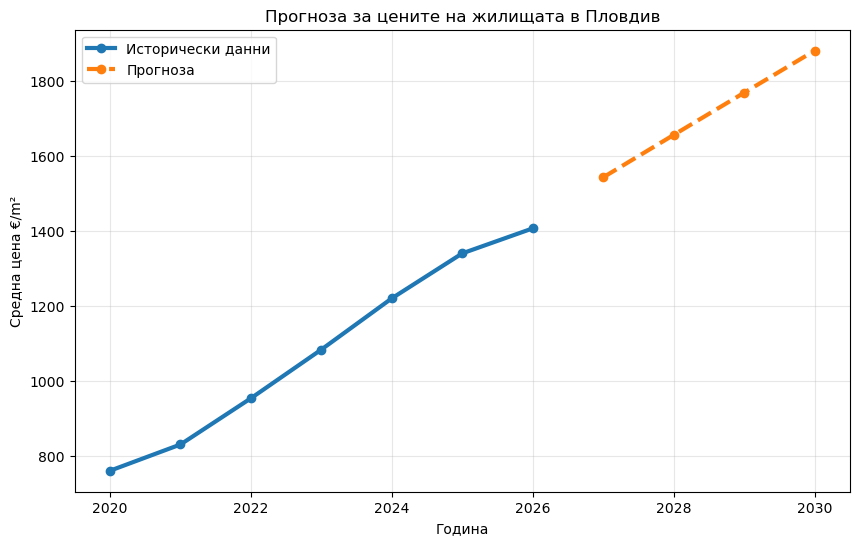


📊 Интерпретация на резултатите:
Моделът показва устойчив растеж на цените на жилищата в Пловдив.
След възход през 2020 г., прогнозата предполага
по-плавно, но продължително покачване на цените.
Ако тенденцията се запази, средната цена може да достигне
около 1800–1900 €/m² до 2030 година.
Източник на данни Eurostat: https://ec.europa.eu/eurostat/web/main/data/database


In [60]:
# ==========================================================
# 📊 Анализ и прогноза на цените на жилищата в Пловдив
# ==========================================================

# ==========================================================
# 1. Импортиране на необходими библиотеки
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# ==========================================================
# 2. Зареждане на набора от данни
# ==========================================================

df = pd.read_csv("housing_data1.csv")

print("Първи редове от набора от данни:")
display(df.head())


# ==========================================================
# 3. Почистване и подготовка на данните
# ==========================================================

# Премахване на запетаи от колоната с общата цена
df["avg_total_price"] = (
    df["avg_total_price"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

#print("\nИнформация за колоните:")
#print(df.info())


# ==========================================================
# 4. Изчисляване на средната цена на m² по години
# ==========================================================

yearly = df.groupby("year")["avg_price_m2_eur"].mean().reset_index()

print("\nСредни цени по години:")
display(yearly)


# ==========================================================
# 5. Създаване на модел за прогнозиране
# Използва се квадратична регресия (Polynomial Regression)
# ==========================================================

X = yearly["year"].values.reshape(-1,1)
y = yearly["avg_price_m2_eur"].values

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)


# ==========================================================
# 6. Прогноза за бъдещи години (2027–2030)
# ==========================================================

future_years = np.arange(2027,2031).reshape(-1,1)

future_poly = poly.transform(future_years)

forecast_prices = model.predict(future_poly)

forecast_df = pd.DataFrame({
    "year": future_years.flatten(),
    "forecast_price_m2": forecast_prices
})

print("\nПрогнозни стойности:")
display(forecast_df)


# ==========================================================
# 7. Визуализация: Исторически данни и прогноза
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    yearly["year"],
    yearly["avg_price_m2_eur"],
    marker="o",
    linewidth=3,
    label="Исторически данни"
)

plt.plot(
    forecast_df["year"],
    forecast_df["forecast_price_m2"],
    marker="o",
    linestyle="--",
    linewidth=3,
    label="Прогноза"
)

plt.xlabel("Година")
plt.ylabel("Средна цена €/m²")

plt.title("Прогноза за цените на жилищата в Пловдив")

plt.grid(alpha=0.3)

plt.legend()

plt.show()


# ==========================================================
# 8. Интерпретация на резултатите
# ==========================================================

print("\n📊 Интерпретация на резултатите:")
print("Моделът показва устойчив растеж на цените на жилищата в Пловдив.")
print("След възход през 2020 г., прогнозата предполага")
print("по-плавно, но продължително покачване на цените.")
print("Ако тенденцията се запази, средната цена може да достигне")
print("около 1800–1900 €/m² до 2030 година.")
print("Източник на данни Eurostat: https://ec.europa.eu/eurostat/web/main/data/database")